In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# PATHS
# ============================================================

results_dir = Path("../data/processed/new_diff")


# ============================================================
# LOAD PyDESeq2 RESULTS
# ============================================================

classical = pd.read_csv(
    results_dir / "CPTAC_Classical_vs_GTEx7_PyDESeq2_results.csv"
)

proneural = pd.read_csv(
    results_dir / "CPTAC_Proneural_vs_GTEx7_PyDESeq2_results.csv"
)

mesenchymal = pd.read_csv(
    results_dir / "CPTAC_Mesenchymal_vs_GTEx7_PyDESeq2_results.csv"
)


# ============================================================
# PREPARE RESULTS FOR VOLCANO PLOT
# ============================================================

def prepare_volcano(results):

    df = results.copy()

    # Remove genes without usable statistics
    df = df.dropna(
        subset=["log2FC", "FDR"]
    )

    # Avoid -log10(0)
    df["FDR"] = df["FDR"].clip(
        lower=np.finfo(float).tiny
    )

    df["-log(adjustedp)"] = (
        -np.log10(df["FDR"])
    )

    # Categories
    df["category"] = "Not Significant"

    df.loc[
        (df["FDR"] < 0.05)
        & (df["log2FC"] > 1),
        "category"
    ] = "Up"

    df.loc[
        (df["FDR"] < 0.05)
        & (df["log2FC"] < -1),
        "category"
    ] = "Down"

    return df


# ============================================================
# PREPARE ALL THREE
# ============================================================

classical_plot = prepare_volcano(classical).set_index("gene_name")

proneural_plot = prepare_volcano(proneural).set_index("gene_name")
mesenchymal_plot = prepare_volcano(mesenchymal).set_index("gene_name")


classical_plot.to_csv("../data/processed/new_diff/CPTAC_Classical_vs_GTEx7_PyDESeq2_results.csv")
proneural_plot.to_csv("../data/processed/new_diff/CPTAC_Proneural_vs_GTEx7_PyDESeq2_results.csv")
mesenchymal_plot.to_csv("../data/processed/new_diff/CPTAC_Mesenchymal_vs_GTEx7_PyDESeq2_results.csv")

In [2]:
# ============================================================
# COUNT SIGNIFICANT GENES
# ============================================================

def count_significant_genes(df, name):

    total = (
        df["FDR"] < 0.05
    ).sum()

    up = (
        (df["FDR"] < 0.05)
        & (df["log2FC"] > 1)
    ).sum()

    down = (
        (df["FDR"] < 0.05)
        & (df["log2FC"] < -1)
    ).sum()

    print(f"\n{name}")
    print("-" * 40)
    print(f"Significant genes (FDR < 0.05): {total}")
    print(f"Upregulated (FDR < 0.05, log2FC > 1): {up}")
    print(f"Downregulated (FDR < 0.05, log2FC < -1): {down}")

    return total, up, down


# ============================================================
# RUN FOR ALL SUBTYPES
# ============================================================

classical_counts = count_significant_genes(
    classical,
    "Classical vs GTEx"
)

proneural_counts = count_significant_genes(
    proneural,
    "Proneural vs GTEx"
)

mesenchymal_counts = count_significant_genes(
    mesenchymal,
    "Mesenchymal vs GTEx"
)


Classical vs GTEx
----------------------------------------
Significant genes (FDR < 0.05): 32067
Upregulated (FDR < 0.05, log2FC > 1): 20328
Downregulated (FDR < 0.05, log2FC < -1): 6949

Proneural vs GTEx
----------------------------------------
Significant genes (FDR < 0.05): 31930
Upregulated (FDR < 0.05, log2FC > 1): 21531
Downregulated (FDR < 0.05, log2FC < -1): 6012

Mesenchymal vs GTEx
----------------------------------------
Significant genes (FDR < 0.05): 32282
Upregulated (FDR < 0.05, log2FC > 1): 20966
Downregulated (FDR < 0.05, log2FC < -1): 6793


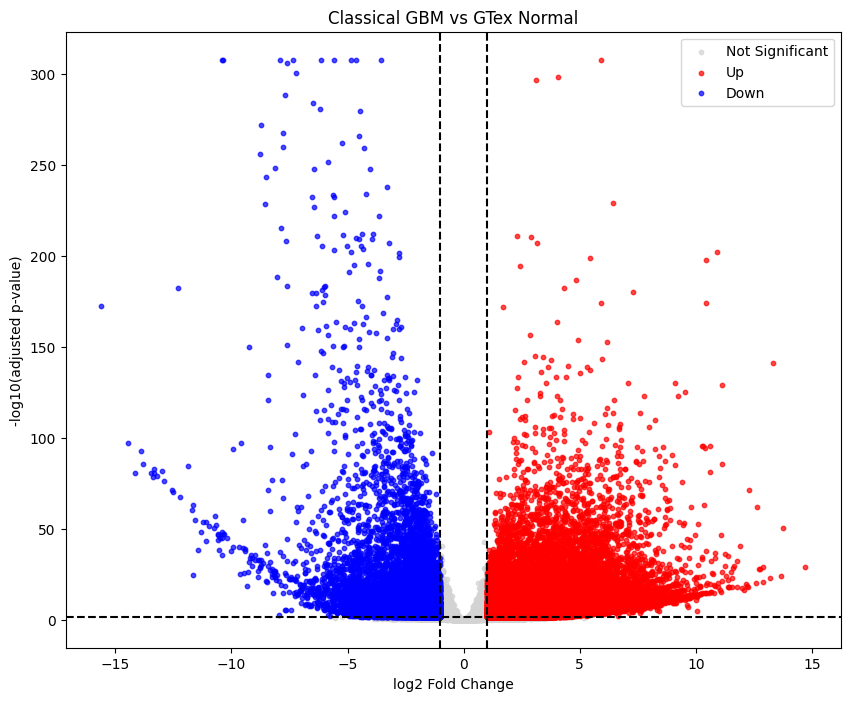

In [3]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)

diff.volcano_plot(classical_plot,"Classical GBM vs GTex Normal")